<a href="https://colab.research.google.com/github/njokinjuguna/ml-learning-labs/blob/main/Dropout_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
#import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

In [55]:
#load the data
df= pd.read_csv('sonar_dataset.csv',header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [56]:
df.shape

(208, 61)

In [57]:
df.isna().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
56,0
57,0
58,0
59,0


In [58]:
#from the above we see there are no null values...next lets check on the column names
df.columns

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
       54, 55, 56, 57, 58, 59, 60],
      dtype='int64')

In [59]:
#column 60 is our target value column lets see what it has
df[60].value_counts()

,count
60,
M,111
R,97


In [60]:
#clearly from the above this is a binary classification dataset...lets separate the X dataset from y target
X=df.drop(60,axis=1)
y=df[60]
y.head()

,60
0,R
1,R
2,R
3,R
4,R


In [61]:
le=LabelEncoder()
df[60]=le.fit_transform(df[60])
y = df[60]



In [62]:
y.value_counts()

,count
60,
0,111
1,97


In [63]:
df.dtypes

,0
0,float64
1,float64
2,float64
3,float64
4,float64
...,...
56,float64
57,float64
58,float64
59,float64


In [64]:
#after being done with preprocessing,we do the data spliting
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=1)



In [65]:
X_train.shape,X_test.shape

((156, 60), (52, 60))

In [66]:
#model construction
model=keras.Sequential([
    keras.layers.Dense(60,input_dim=60,activation='relu'),
    keras.layers.Dense(20,activation='relu'),
    keras.layers.Dense(10,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
])
model.compile(
     optimizer='adam',
     loss='binary_crossentropy',
     metrics=['accuracy']
 )
model.fit(X_train,y_train,epochs=100,batch_size=8)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4936 - loss: 0.6996
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6154 - loss: 0.6795 
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6538 - loss: 0.6676 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6538 - loss: 0.6501 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7244 - loss: 0.6257 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7500 - loss: 0.5999 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7115 - loss: 0.5720
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7308 - loss: 0.5384 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7885 - loss: 0.5124
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7821 - loss: 0.4797 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8333 - loss: 0.4509 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - a

In [67]:
#model evaluation
model.evaluate(X_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7692 - loss: 0.9609 


[0.9609369039535522, 0.7692307829856873]

In [68]:
#model prediction
y_pred=model.predict(X_test)
y_pred=np.round(y_pred)
y_pred[:10]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([[0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.]], dtype=float32)

In [69]:
y_train[:10]

,60
67,1
14,1
164,0
179,0
19,1
99,0
88,1
39,1
114,0
132,0


In [70]:
#confusion metric report
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.74      0.85      0.79        27
           1       0.81      0.68      0.74        25

    accuracy                           0.77        52
   macro avg       0.78      0.77      0.77        52
weighted avg       0.77      0.77      0.77        52



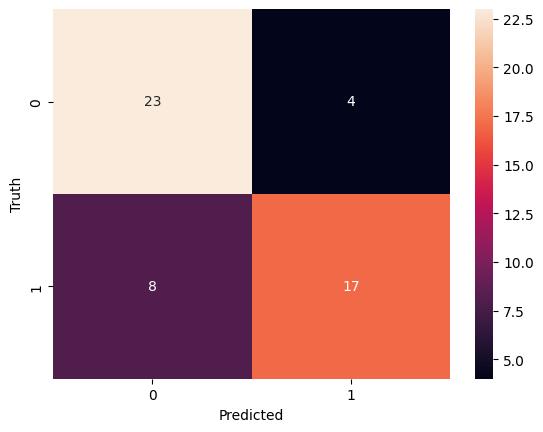

In [71]:
#confusion_matrix graph
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

dropout regularization

In [72]:
#to fix the overfitting issue, lets apply the dropout regularization
#model construction
model_dropout=keras.Sequential([
    keras.layers.Dense(60,input_dim=60,activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(20,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10,activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1,activation='sigmoid')
])
model_dropout.compile(
     optimizer='adam',
     loss='binary_crossentropy',
     metrics=['accuracy']
 )
model_dropout.fit(X_train,y_train,epochs=100,batch_size=8)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4103 - loss: 0.7410
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5000 - loss: 0.7075
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5449 - loss: 0.6947
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4744 - loss: 0.6980
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5577 - loss: 0.6893
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5128 - loss: 0.6949
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5000 - loss: 0.6913
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4872 - loss: 0.6910
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5513 - loss: 0.6827
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5641 - loss: 0.6755
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6154 - loss: 0.6621
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy:

In [73]:
#model evaluation
model_dropout.evaluate(X_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7885 - loss: 0.5049 


[0.5049496293067932, 0.7884615659713745]

In [74]:
#model prediction
y_pred_dropout=model_dropout.predict(X_test)
y_pred_dropout=np.round(y_pred_dropout)
y_pred_dropout[:10]

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


array([[0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.]], dtype=float32)

In [75]:
#classification report
cr_dropout=classification_report(y_test,y_pred_dropout)
print(cr_dropout)

              precision    recall  f1-score   support

           0       0.75      0.89      0.81        27
           1       0.85      0.68      0.76        25

    accuracy                           0.79        52
   macro avg       0.80      0.78      0.78        52
weighted avg       0.80      0.79      0.79        52



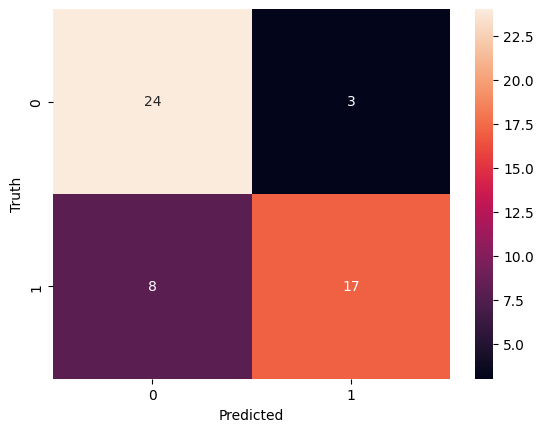

In [76]:
#confusion metrrix
cm_dropout=confusion_matrix(y_test,y_pred_dropout)
sns.heatmap(cm_dropout,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()